In [1]:
import re
import json
import glob

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import scienceplots
plt.style.use(["ieee", "no-latex"])
plt.rcParams["figure.dpi"] = 300

## Metrics

In [7]:
df = pd.concat([pd.read_csv(x) for x in glob.glob("../data/evals/*.csv")], ignore_index=True)
df.head()

,model,stemming_model,stemming_eval,metric,k,value
0,../models/ams-bow.joblib,False,False,NDCG,1,0.23829
1,../models/ams-bow.joblib,False,False,NDCG,3,0.31937
2,../models/ams-bow.joblib,False,False,NDCG,5,0.34536
3,../models/ams-bow.joblib,False,False,NDCG,10,0.37132
4,../models/ams-bow.joblib,False,False,NDCG,100,0.42057


In [13]:
df["fine_tuned"] = df["model"].str.contains("ams")
df["category"] = np.where(df["model"].str.contains("bow|tfidf|doc2vec|fasttext"), "traditional", "bert")
df["model_name"] = (df["model"].str.split("/") 
    .str[-1] 
    .str.replace("ams-|-stem|\.joblib|\.gensim", "", regex=True)
)

df = df.drop(columns=["model"])
df.head()

,stemming_model,stemming_eval,metric,k,value,model_name,category,fine_tuned
0,False,False,NDCG,1,0.23829,bow,traditional,True
1,False,False,NDCG,3,0.31937,bow,traditional,True
2,False,False,NDCG,5,0.34536,bow,traditional,True
3,False,False,NDCG,10,0.37132,bow,traditional,True
4,False,False,NDCG,100,0.42057,bow,traditional,True


In [14]:
df.to_csv("../data/eval-all.csv", index=False, sep=";", decimal=",")

In [17]:
dd = df[(df["k"] == 5) & (~df["stemming_eval"])].pivot_table(index=["stemming_model", "model_name"], columns=["fine_tuned", "metric"], values="value")
dd

fine_tuned                                   False                             \
metric                                         MAP     NDCG        P   Recall   
stemming_model model_name                                                       
False          all-mpnet-base-v2           0.13347  0.14865  0.03890  0.19450   
               all-mpnet-base-v2-100           NaN      NaN      NaN      NaN   
               all-mpnet-base-v2-50            NaN      NaN      NaN      NaN   
               bow                             NaN      NaN      NaN      NaN   
               doc2vec                         NaN      NaN      NaN      NaN   
               fasttext                        NaN      NaN      NaN      NaN   
               msmarco-MiniLM-L6-cos-v5    0.12065  0.13345  0.03444  0.17221   
               msmarco-distilbert-cos-v5   0.07675  0.08472  0.02176  0.10880   
               multi-qa-MiniLM-L6-cos-v1   0.14309  0.15852  0.04104  0.20518   
               multi-qa-distilbert-cos-v1  0.13082  0.14559  0.03805  0.19023   
               tf-idf                          NaN      NaN      NaN      NaN   
True           all-mpnet-base-v2               NaN      NaN      NaN      NaN   
               bow                             NaN      NaN      NaN      NaN   
               doc2vec                         NaN      NaN      NaN      NaN   
               fasttext                        NaN      NaN      NaN      NaN   
               msmarco-MiniLM-L6-cos-v5        NaN      NaN      NaN      NaN   
               msmarco-distilbert-cos-v5       NaN      NaN      NaN      NaN   
               multi-qa-MiniLM-L6-cos-v1       NaN      NaN      NaN      NaN   
               multi-qa-distilbert-cos-v1      NaN      NaN      NaN      NaN   
               tf-idf                          NaN      NaN      NaN      NaN   

fine_tuned                                   True                              
metric                                         MAP     NDCG        P   Recall  
stemming_model model_name                                                      
False          all-mpnet-base-v2           0.25503  0.27966  0.07072  0.35362  
               all-mpnet-base-v2-100       0.24459  0.26762  0.06733  0.33667  
               all-mpnet-base-v2-50        0.25681  0.28044  0.07027  0.35135  
               bow                         0.31391  0.34536  0.08800  0.43999  
               doc2vec                     0.03657  0.04331  0.01276  0.06381  
               fasttext                    0.02434  0.02931  0.00892  0.04459  
               msmarco-MiniLM-L6-cos-v5    0.20951  0.22959  0.05799  0.28995  
               msmarco-distilbert-cos-v5   0.25513  0.27938  0.07048  0.35242  
               multi-qa-MiniLM-L6-cos-v1   0.21844  0.24216  0.06280  0.31398  
               multi-qa-distilbert-cos-v1  0.26283  0.28750  0.07235  0.36177  
               tf-idf                      0.50750  0.54795  0.13379  0.66894  
True           all-mpnet-base-v2           0.24492  0.27054  0.06955  0.34775  
               bow                         0.27846  0.31028  0.08140  0.40702  
               doc2vec                     0.03659  0.04287  0.01241  0.06207  
               fasttext                    0.02471  0.03005  0.00929  0.04646  
               msmarco-MiniLM-L6-cos-v5    0.18705  0.20744  0.05385  0.26926  
               msmarco-distilbert-cos-v5   0.23069  0.25273  0.06378  0.31892  
               multi-qa-MiniLM-L6-cos-v1   0.20490  0.22686  0.05860  0.29302  
               multi-qa-distilbert-cos-v1  0.24492  0.26749  0.06704  0.33520  
               tf-idf                      0.42054  0.46524  0.12033  0.60166

## Training History

In [74]:
train_history = []

for file_path in glob.glob("../data/tuning-logs/*.log"):
    with open(file_path, "r") as f:
        current_run = {"max_epochs": int(re.search(r"\d+", file_path).group(0))}
        for line in f:
            if line.startswith("Namespace"):
                current_run["model"] = re.search(r"model_name='(.+?)'", line).group(1)[22:]
                current_run["stemming"] = "stemming=True" in line

            if line.startswith("{'loss':"):
                line = line.replace("'", "\"").replace("inf", "-1")
                parsed = json.loads(line)
                train_history.append({
                    **current_run,
                    "epoch": parsed["epoch"],
                    "epoch_ceil": int(np.ceil(parsed["epoch"])),
                    "loss": parsed["loss"],
                })

In [ ]:
df_history = pd.DataFrame(train_history)
df_history = df_history.groupby(["max_epochs", "model", "stemming", "epoch_ceil"]).mean().reset_index() # summarize per epoch
df_history

,max_epochs,model,stemming,epoch_ceil,epoch,loss
0,10,all-mpnet-base-v2,False,1,0.506667,0.834739
1,10,all-mpnet-base-v2,False,2,1.493158,0.510495
2,10,all-mpnet-base-v2,False,3,2.506842,0.301421
3,10,all-mpnet-base-v2,False,4,3.522632,0.164079
4,10,all-mpnet-base-v2,False,5,4.510000,0.091739
...,...,...,...,...,...,...
245,100,all-mpnet-base-v2,False,96,95.520000,0.001800
246,100,all-mpnet-base-v2,False,97,96.315000,0.001350
247,100,all-mpnet-base-v2,False,98,97.385000,0.000900
248,100,all-mpnet-base-v2,False,99,98.455000,0.000500


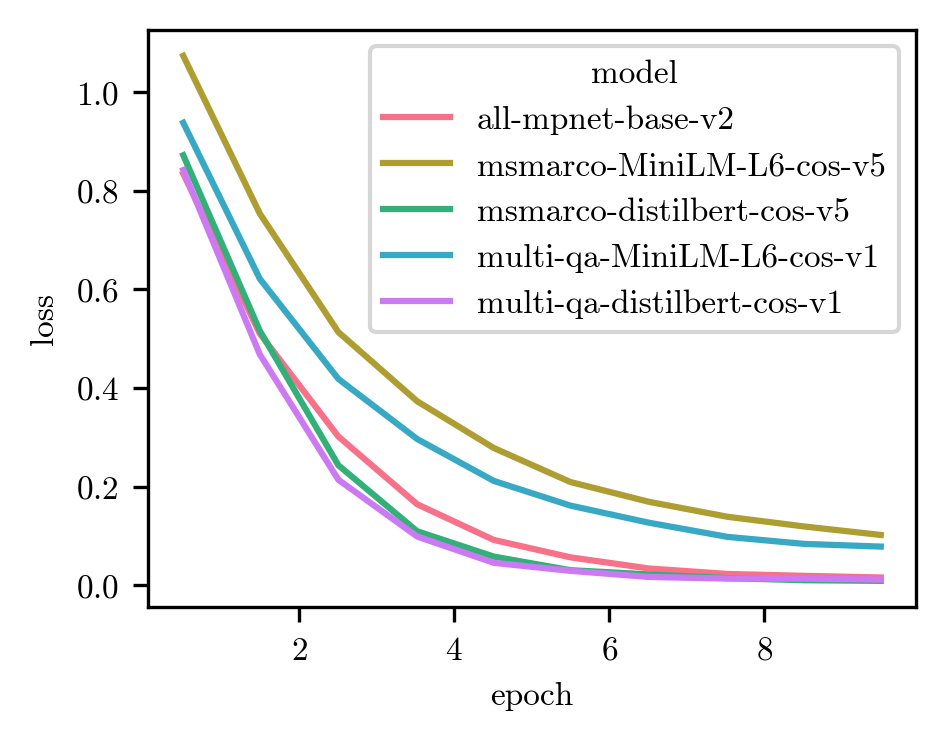

In [76]:
dd_filters = (df_history["stemming"] == False) & (df_history["max_epochs"] == 10)

sns.lineplot(df_history[dd_filters], x="epoch", y="loss", hue="model")
plt.show()

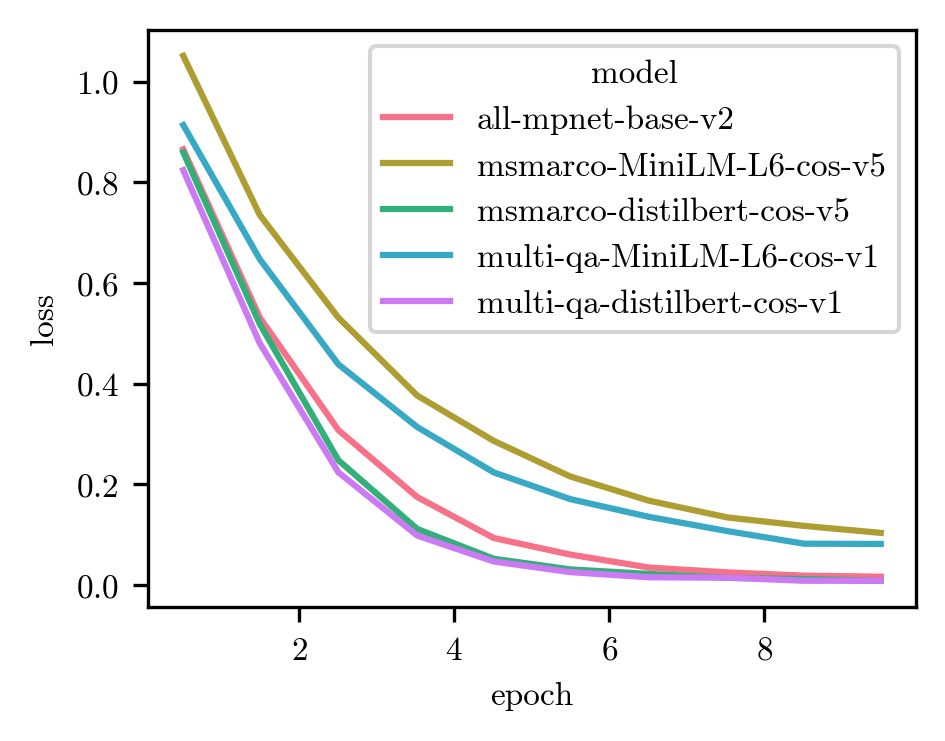

In [77]:
dd_filters = (df_history["stemming"] == True) & (df_history["max_epochs"] == 10)

sns.lineplot(df_history[dd_filters], x="epoch", y="loss", hue="model")
plt.show()